In [1]:
# Problema: Decidir, antes de la temporada de incendios, en cuáles bases activar recursos de respuesta para minimizar el tiempo esperado de llegada a zonas de riesgo dispersas.
# Antes del incendio decidimos donde posicionar recursos; el riesgo es un insumo, no la decision.

from pathlib import Path
from itertools import combinations
from math import comb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import display
from IPython import get_ipython
import pulp

data_dir = Path("../data")
submission_dir = Path("../submission")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
display(["risk_zones.csv", "candidate_bases.csv", "deployment_parameters.csv"])

['risk_zones.csv', 'candidate_bases.csv', 'deployment_parameters.csv']

In [2]:
# Caso sintetico: Distrito Sierra Alta, geografia ficticia para practicar posicionamiento espacial.

zones = pd.read_csv(data_dir / "risk_zones.csv").sort_values("zone_id").reset_index(drop=True)
bases = pd.read_csv(data_dir / "candidate_bases.csv").sort_values("base_id").reset_index(drop=True)
parameters = pd.read_csv(data_dir / "deployment_parameters.csv")
P = int(parameters.loc[0, "bases_to_activate"])
speed = float(parameters.loc[0, "average_response_speed_kmh"])
display(zones, bases, parameters)

,zone_id,x_km,y_km,risk_weight
0,Z01,10,85,0.20
1,Z02,20,70,0.07
2,Z03,35,90,0.08
3,Z04,55,55,0.10
4,Z05,85,65,0.18
5,Z06,90,45,0.07
6,Z07,55,15,0.17
7,Z08,30,20,0.13


,base_id,x_km,y_km
0,B01,12,80
1,B02,88,60
2,B03,50,45
3,B04,50,15
4,B05,25,25
5,B06,60,65


,parameter_id,bases_to_activate,average_response_speed_kmh
0,BASE,2,45


In [3]:
# El riesgo se reparte como pesos que suman uno: el objetivo sera tiempo de respuesta esperado.

assert len(zones) == 8 and zones.zone_id.is_unique
assert len(bases) == 6 and bases.base_id.is_unique
assert not zones.isna().any().any() and not bases.isna().any().any()
assert np.isclose(zones.risk_weight.sum(), 1.0)
assert zones.risk_weight.between(0, 1).all()
assert 1 <= P <= len(bases) and speed > 0
print(f"{len(zones)} zonas de riesgo; {len(bases)} bases candidatas; activar P={P}; velocidad {speed:.0f} km/h.")

8 zonas de riesgo; 6 bases candidatas; activar P=2; velocidad 45 km/h.


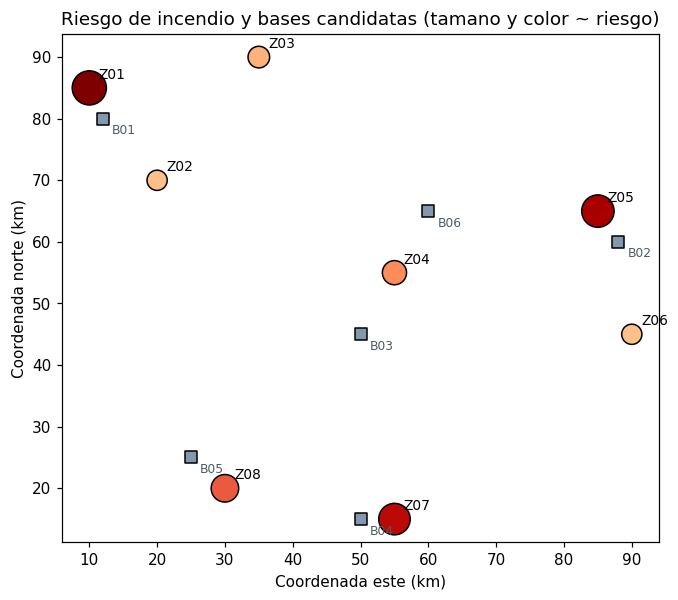

In [4]:
# El riesgo describe el terreno; todavia no dice donde posicionar recursos.

fig_risk, ax_risk = plt.subplots(figsize=(7, 6))
ax_risk.scatter(
    zones.x_km, zones.y_km, s=zones.risk_weight * 2500, c=zones.risk_weight,
    cmap="OrRd", edgecolor="black", vmin=0, vmax=zones.risk_weight.max()
)
for row in zones.itertuples():
    ax_risk.annotate(row.zone_id, (row.x_km, row.y_km), xytext=(6, 6), textcoords="offset points", fontsize=9)
ax_risk.scatter(bases.x_km, bases.y_km, marker="s", c="#8299ad", s=70, edgecolor="black")
for row in bases.itertuples():
    ax_risk.annotate(
        row.base_id, (row.x_km, row.y_km), xytext=(6, -10), textcoords="offset points",
        fontsize=8, color="#4a5b66"
    )
ax_risk.set(
    xlabel="Coordenada este (km)", ylabel="Coordenada norte (km)",
    title="Riesgo de incendio y bases candidatas (tamano y color ~ riesgo)",
)
plt.show()

In [5]:
# La distancia euclidiana en un plano de kilometros basta: no se requieren datos GIS reales.

zone_ids = zones.zone_id.tolist()
base_ids = bases.base_id.tolist()
zone_xy = zones.set_index("zone_id")[["x_km", "y_km"]]
base_xy = bases.set_index("base_id")[["x_km", "y_km"]]
distance_km = pd.DataFrame(
    {j: np.hypot(zone_xy.x_km - base_xy.loc[j, "x_km"], zone_xy.y_km - base_xy.loc[j, "y_km"]) for j in base_ids}
)
response_time = 60 * distance_km / speed
display(response_time.round(1))

,B01,B02,B03,B04,B05,B06
zone_id,,,,,,
Z01,7.2,109.2,75.4,107.5,82.5,71.8
Z02,17.1,91.6,52.1,83.5,60.4,53.7
Z03,33.4,81.2,63.2,102.0,87.7,47.1
Z04,66.3,44.5,14.9,53.7,56.6,14.9
Z05,99.4,7.8,53.7,81.4,96.1,33.3
Z06,114.0,20.2,53.3,66.7,90.7,48.1
Z07,103.9,74.4,40.6,6.7,42.2,67.0
Z08,83.5,93.9,42.7,27.5,9.4,72.1


In [6]:
# Cada zona ya tiene una base mas cercana en el mapa completo, sin activar todavia ninguna.

nearest_overall = response_time.idxmin(axis=1)
display(pd.DataFrame({"zone_id": zone_ids, "nearest_base": nearest_overall.values}))

,zone_id,nearest_base
0,Z01,B01
1,Z02,B01
2,Z03,B01
3,Z04,B03
4,Z05,B02
5,Z06,B02
6,Z07,B04
7,Z08,B05


In [7]:
# Heuristica 1: posicionar cerca de las zonas de mayor riesgo individual.

def risk_first_bases(p):
    chosen = []
    for zid in zones.sort_values("risk_weight", ascending=False).zone_id:
        for bid in response_time.loc[zid].sort_values().index:
            if bid not in chosen:
                chosen.append(bid)
                break
        if len(chosen) == p:
            break
    return tuple(sorted(chosen))

risk_first_selection = risk_first_bases(P)
print(f"Bases sugeridas por riesgo individual: {risk_first_selection}")

Bases sugeridas por riesgo individual: ('B01', 'B02')


In [8]:
# El mismo criterio evaluara heuristicas y optimizacion: tiempo de respuesta esperado ponderado por riesgo.

risk_weight = zones.set_index("zone_id").risk_weight

def evaluate_deployment(active_bases):
    active_bases = list(active_bases)
    nearest_time = response_time[active_bases].min(axis=1)
    nearest_base = response_time[active_bases].idxmin(axis=1)
    weighted_time = float((risk_weight * nearest_time).sum())
    assignment = nearest_base.to_dict()
    return weighted_time, assignment

print("Funcion de evaluacion definida: asigna cada zona a su base activa mas cercana.")

Funcion de evaluacion definida: asigna cada zona a su base activa mas cercana.


In [9]:
# Evaluamos la heuristica de riesgo individual con el criterio compartido.

risk_first_objective, risk_first_assignment = evaluate_deployment(risk_first_selection)
print(f"Riesgo individual -> bases {risk_first_selection}; tiempo esperado {risk_first_objective:.2f} min")

Riesgo individual -> bases ('B01', 'B02'); tiempo esperado 36.08 min


In [10]:
# Heuristica 2: posicionar en las bases geograficamente mas centrales, ignorando el riesgo.

average_response_time = response_time.mean(axis=0)
centrality_selection = tuple(sorted(average_response_time.sort_values().index[:P]))
display(average_response_time.sort_values().rename("avg_response_time_min"))

B03    49.495836
B06    51.014463
B02    65.356771
B01    65.601028
B05    65.687812
B04    66.119548
Name: avg_response_time_min, dtype: float64

In [11]:
# Evaluamos la heuristica de centralidad con el mismo criterio.

centrality_objective, centrality_assignment = evaluate_deployment(centrality_selection)
print(f"Centralidad geografica -> bases {centrality_selection}; tiempo esperado {centrality_objective:.2f} min")

Centralidad geografica -> bases ('B03', 'B06'); tiempo esperado 45.08 min


In [12]:
# Ambas heuristicas usan un solo criterio; ninguna considera la interaccion espacial completa.

heuristics_preview = pd.DataFrame(
    [
        ["riesgo individual", risk_first_selection, risk_first_objective],
        ["centralidad geografica", centrality_selection, centrality_objective],
    ],
    columns=["estrategia", "bases", "tiempo_esperado_min"],
)
display(heuristics_preview)

,estrategia,bases,tiempo_esperado_min
0,riesgo individual,"(B01, B02)",36.075167
1,centralidad geografica,"(B03, B06)",45.075524


In [13]:
# Sin restriccion de capacidad, asignar cada zona a su base activa mas cercana ya es optimo dado y.

deployment_configs = []
for combo in combinations(base_ids, P):
    objective, assignment = evaluate_deployment(combo)
    deployment_configs.append((objective, tuple(sorted(combo)), assignment))
deployment_configs.sort(key=lambda item: item[0])
print(f"{comb(len(base_ids), P)} despliegues evaluados exhaustivamente sobre las bases activas.")

15 despliegues evaluados exhaustivamente sobre las bases activas.


In [14]:
# La unicidad separa una recomendacion concreta de alternativas empatadas.

exhaustive_objective, exhaustive_bases, exhaustive_assignment = deployment_configs[0]
optimal_count = sum(np.isclose(item[0], exhaustive_objective) for item in deployment_configs)
second_best_objective = deployment_configs[1][0]
display(
    pd.DataFrame(
        [(obj, bases_) for obj, bases_, _ in deployment_configs[:2]],
        columns=["expected_response_time_min", "active_bases"],
    )
)
print(f"Optimos encontrados: {optimal_count}")

,expected_response_time_min,active_bases
0,32.648407,"(B01, B03)"
1,34.702544,"(B01, B04)"


Optimos encontrados: 1


In [15]:
# La enumeracion expone el razonamiento espacial, pero no escala a redes reales de bases.

print(f"C({len(base_ids)}, {P}) = {comb(len(base_ids), P)} configuraciones evaluadas aqui.")
print(f"Con 30 bases candidatas y P=6: C(30, 6) = {comb(30, 6):,} configuraciones.")

C(6, 2) = 15 configuraciones evaluadas aqui.
Con 30 bases candidatas y P=6: C(30, 6) = 593,775 configuraciones.


In [16]:
# MODEL
# ---------------------------------------------------------------------
# Sets:
#   i in ZONES
#   j in BASES
#
# Parameters:
#   w[i]          wildfire risk weight at zone i
#   t[i,j]        response time from base j to zone i
#   P             number of bases to activate
#
# Decision variables:
#   y[j] binary
#       1 if candidate base j is activated
#
#   x[i,j] binary
#       1 if risk zone i is assigned to base j
#
# Objective:
#   minimize expected_response_time:
#       sum{i in ZONES, j in BASES}
#           w[i] * t[i,j] * x[i,j]
#
# Constraints:
#   subject to one_base{i in ZONES}:
#       sum{j in BASES} x[i,j] = 1
#
#   subject to active_base{i in ZONES, j in BASES}:
#       x[i,j] <= y[j]
#
#   subject to activation_count:
#       sum{j in BASES} y[j] = P

display(pd.Series({"zones": len(zone_ids), "candidate_bases": len(base_ids), "bases_to_activate": P}))
print("Como sum(w[i]) = 1, el objetivo se interpreta como minutos esperados de respuesta ponderados por riesgo.")

zones                8
candidate_bases      6
bases_to_activate    2
dtype: int64

Como sum(w[i]) = 1, el objetivo se interpreta como minutos esperados de respuesta ponderados por riesgo.


In [17]:
# Construimos el mismo modelo con PuLP; HiGHS lo resolvera a continuacion.

model = pulp.LpProblem("wildfire_resource_positioning", pulp.LpMinimize)
y = {j: pulp.LpVariable(f"y_{j}", cat="Binary") for j in base_ids}
x = {(i, j): pulp.LpVariable(f"x_{i}_{j}", cat="Binary") for i in zone_ids for j in base_ids}
model += pulp.lpSum(risk_weight.loc[i] * response_time.loc[i, j] * x[i, j] for i in zone_ids for j in base_ids)
for i in zone_ids:
    model += pulp.lpSum(x[i, j] for j in base_ids) == 1
for i in zone_ids:
    for j in base_ids:
        model += x[i, j] <= y[j]
model += pulp.lpSum(y[j] for j in base_ids) == P
display(
    pd.Series(
        {
            "y_variables": len(y),
            "x_variables": len(x),
            "one_base_constraints": len(zone_ids),
            "active_base_constraints": len(zone_ids) * len(base_ids),
            "activation_count_constraints": 1,
        }
    )
)

y_variables                      6
x_variables                     48
one_base_constraints             8
active_base_constraints         48
activation_count_constraints     1
dtype: int64

In [18]:
# Resolvemos el mismo modelo con un solver profesional en lugar de enumeracion.

solver = pulp.HiGHS(msg=False)
status = model.solve(solver)
assert pulp.LpStatus[status] == "Optimal"
solver_objective = pulp.value(model.objective)
solver_bases = tuple(sorted(j for j in base_ids if y[j].value() > 0.5))
solver_assignment = {i: j for i in zone_ids for j in base_ids if x[i, j].value() > 0.5}
display(pd.DataFrame({"base_id": solver_bases}).assign(y=1))
display(
    pd.DataFrame(
        {"zone_id": list(solver_assignment.keys()), "base_id": list(solver_assignment.values())}
    ).assign(x=1)
)
print(f"Estado: {pulp.LpStatus[status]}; objetivo HiGHS: {solver_objective:.3f} min")

,base_id,y
0,B01,1
1,B03,1


,zone_id,base_id,x
0,Z01,B01,1
1,Z02,B01,1
2,Z03,B01,1
3,Z04,B03,1
4,Z05,B03,1
5,Z06,B03,1
6,Z07,B03,1
7,Z08,B03,1


Estado: Optimal; objetivo HiGHS: 32.648 min


In [19]:
# La busqueda exhaustiva expone el razonamiento; el solver lo resuelve de forma escalable.

assert np.isclose(solver_objective, exhaustive_objective)
assert solver_bases == exhaustive_bases
assert solver_assignment == exhaustive_assignment
assert len(solver_bases) == P
assert set(solver_assignment.keys()) == set(zone_ids)
assert all(base in solver_bases for base in solver_assignment.values())
recomputed_objective = sum(risk_weight.loc[i] * response_time.loc[i, solver_assignment[i]] for i in zone_ids)
assert np.isclose(recomputed_objective, solver_objective)
print(f"Exhaustive search objective : {exhaustive_objective:.3f}")
print(f"HiGHS objective             : {solver_objective:.3f}")
print(f"Bases agree                 : {solver_bases == exhaustive_bases}")
print(f"Assignments agree           : {solver_assignment == exhaustive_assignment}")
print(f"Solver status               : {pulp.LpStatus[status]}")

Exhaustive search objective : 32.648
HiGHS objective             : 32.648
Bases agree                 : True
Assignments agree           : True
Solver status               : Optimal


In [20]:
# El optimo revela cuanto queda sobre la mesa al usar un solo criterio de posicionamiento.

strategy_comparison = pd.DataFrame(
    [
        ["riesgo individual", risk_first_selection, risk_first_objective],
        ["centralidad geografica", centrality_selection, centrality_objective],
        ["optimo espacial", exhaustive_bases, exhaustive_objective],
    ],
    columns=["estrategia", "bases_activadas", "tiempo_esperado_min"],
)
strategy_comparison["brecha_min"] = strategy_comparison.tiempo_esperado_min - exhaustive_objective
display(strategy_comparison)

,estrategia,bases_activadas,tiempo_esperado_min,brecha_min
0,riesgo individual,"(B01, B02)",36.075167,3.426760
1,centralidad geografica,"(B03, B06)",45.075524,12.427117
2,optimo espacial,"(B01, B03)",32.648407,0.000000


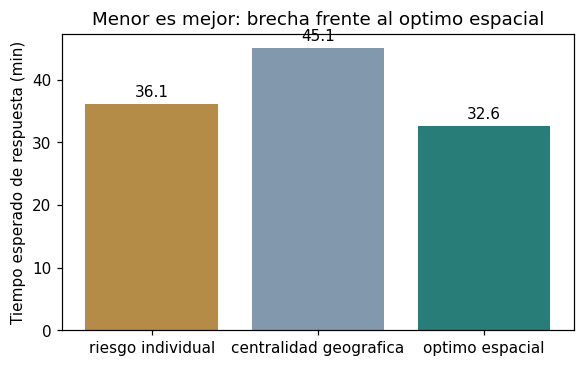

In [21]:
# Ninguna heuristica de un solo criterio iguala al posicionamiento optimo.

fig_cmp, ax_cmp = plt.subplots(figsize=(6, 3.5))
bars = ax_cmp.bar(
    strategy_comparison.estrategia, strategy_comparison.tiempo_esperado_min,
    color=["#b48b47", "#8299ad", "#287d78"]
)
ax_cmp.bar_label(bars, fmt="%.1f", padding=3)
ax_cmp.set(
    ylabel="Tiempo esperado de respuesta (min)",
    title="Menor es mejor: brecha frente al optimo espacial",
)
plt.show()

In [22]:
# Con la base mas atractiva por riesgo fija, comparamos que segunda base cubre mejor el resto.

fixed_base = exhaustive_bases[0]
alternative_partners = sorted(set(risk_first_selection) | set(exhaustive_bases))
alternative_partners = [b for b in alternative_partners if b != fixed_base]
partner_rows = []
for partner in alternative_partners:
    obj, _ = evaluate_deployment([fixed_base, partner])
    partner_rows.append([partner, obj])
partner_comparison = pd.DataFrame(partner_rows, columns=["socio_de_base_fija", "tiempo_esperado_min"])
display(partner_comparison)

,socio_de_base_fija,tiempo_esperado_min
0,B02,36.075167
1,B03,32.648407


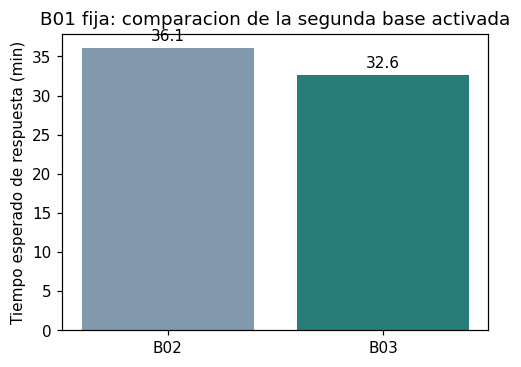

In [23]:
# La base cercana a un solo foco de riesgo no siempre cubre mejor el resto del distrito.

fig_partner, ax_partner = plt.subplots(figsize=(5, 3.5))
bars = ax_partner.bar(
    partner_comparison.socio_de_base_fija, partner_comparison.tiempo_esperado_min,
    color=["#8299ad", "#287d78"]
)
ax_partner.bar_label(bars, fmt="%.1f", padding=3)
ax_partner.set(
    ylabel="Tiempo esperado de respuesta (min)",
    title=f"{fixed_base} fija: comparacion de la segunda base activada",
)
plt.show()

In [24]:
# Resolvemos el mismo problema para distintos niveles de recurso disponible.

sensitivity_rows = []
previous_objective = None
for p_value in [1, 2, 3]:
    configs = sorted(
        (evaluate_deployment(combo) + (tuple(sorted(combo)),) for combo in combinations(base_ids, p_value)),
        key=lambda item: (item[0], item[2]),
    )
    best_objective, _, best_bases = configs[0]
    improvement = None if previous_objective is None else previous_objective - best_objective
    sensitivity_rows.append([p_value, ";".join(best_bases), best_objective, improvement])
    previous_objective = best_objective
resource_sensitivity = pd.DataFrame(
    sensitivity_rows,
    columns=["bases_to_activate", "active_bases", "expected_response_time_min", "marginal_improvement_min"],
)
display(resource_sensitivity)

,bases_to_activate,active_bases,expected_response_time_min,marginal_improvement_min
0,1,B03,51.131299,NaN
1,2,B01;B03,32.648407,18.482892
2,3,B01;B02;B04,17.275208,15.373198


In [25]:
# Mas bases no empeoran el resultado, pero el conjunto optimo puede no estar anidado.

sensitivity_sets = [set(value.split(";")) for value in resource_sensitivity.active_bases]
for k in range(len(sensitivity_sets) - 1):
    entered = sorted(sensitivity_sets[k + 1] - sensitivity_sets[k])
    left = sorted(sensitivity_sets[k] - sensitivity_sets[k + 1])
    p_before = resource_sensitivity.bases_to_activate.iloc[k]
    p_after = resource_sensitivity.bases_to_activate.iloc[k + 1]
    nested = sensitivity_sets[k].issubset(sensitivity_sets[k + 1])
    print(f"P={p_before} -> P={p_after}: entra {entered}; sale {left}; anidado: {nested}")

P=1 -> P=2: entra ['B01']; sale []; anidado: True
P=2 -> P=3: entra ['B02', 'B04']; sale ['B03']; anidado: False


In [26]:
# Registramos que bases se activan en la recomendacion base (P de referencia del caso).

deployment_decisions = bases.copy()
deployment_decisions["activated"] = deployment_decisions.base_id.isin(solver_bases).astype(int)
display(deployment_decisions)

,base_id,x_km,y_km,activated
0,B01,12,80,1
1,B02,88,60,0
2,B03,50,45,1
3,B04,50,15,0
4,B05,25,25,0
5,B06,60,65,0


In [27]:
# Cada zona reporta a su base activa mas cercana; el riesgo pondera su contribucion al objetivo.

zone_assignments = zones.copy()
zone_assignments["assigned_base"] = zone_assignments.zone_id.map(solver_assignment)
zone_assignments["distance_km"] = zone_assignments.apply(
    lambda row: distance_km.loc[row.zone_id, row.assigned_base], axis=1
)
zone_assignments["response_time_min"] = zone_assignments.apply(
    lambda row: response_time.loc[row.zone_id, row.assigned_base], axis=1
)
zone_assignments["weighted_response_contribution"] = (
    zone_assignments.risk_weight * zone_assignments.response_time_min
)
display(
    zone_assignments[
        [
            "zone_id", "assigned_base", "risk_weight", "distance_km",
            "response_time_min", "weighted_response_contribution",
        ]
    ]
)

,zone_id,assigned_base,risk_weight,distance_km,response_time_min,weighted_response_contribution
0,Z01,B01,0.20,5.385165,7.180220,1.436044
1,Z02,B01,0.07,12.806248,17.074998,1.195250
2,Z03,B01,0.08,25.079872,33.439830,2.675186
3,Z04,B03,0.10,11.180340,14.907120,1.490712
4,Z05,B03,0.18,40.311289,53.748385,9.674709
5,Z06,B03,0.07,40.000000,53.333333,3.733333
6,Z07,B03,0.17,30.413813,40.551750,6.893798
7,Z08,B03,0.13,32.015621,42.687495,5.549374


In [28]:
# Construimos el mapa de despliegue sin mostrarlo hasta completar todas sus capas.

base_colors = dict(zip(base_ids, plt.get_cmap("tab10").colors))
planner = Figure(figsize=(10, 8), layout="constrained")
map_ax = planner.add_subplot(111)
inactive_bases = bases[~bases.base_id.isin(solver_bases)]
active_bases_df = bases[bases.base_id.isin(solver_bases)]
active_lookup = active_bases_df.set_index("base_id")
map_ax.scatter(
    inactive_bases.x_km, inactive_bases.y_km, marker="s", s=110, c="#c7d0d6",
    edgecolor="black", zorder=2, label="Base candidata (no activada)"
)
map_ax.scatter(
    zone_assignments.x_km, zone_assignments.y_km, s=zone_assignments.risk_weight * 2500,
    c=zone_assignments.risk_weight, cmap="OrRd", edgecolor="black", zorder=3,
    label="Zona de riesgo (tamano y color ~ riesgo)"
)
for row in zone_assignments.itertuples():
    color = base_colors[row.assigned_base]
    map_ax.plot(
        [row.x_km, active_lookup.loc[row.assigned_base, "x_km"]],
        [row.y_km, active_lookup.loc[row.assigned_base, "y_km"]],
        color=color, linewidth=1.4, alpha=0.7, zorder=1,
    )
map_ax.scatter(
    active_bases_df.x_km, active_bases_df.y_km, marker="*", s=550,
    c=[base_colors[b] for b in active_bases_df.base_id], edgecolor="black", zorder=4,
    label="Base activada"
)
for row in zone_assignments.itertuples():
    map_ax.annotate(row.zone_id, (row.x_km, row.y_km), xytext=(6, 6), textcoords="offset points", fontsize=9)
for row in bases.itertuples():
    map_ax.annotate(
        row.base_id, (row.x_km, row.y_km), xytext=(6, -11), textcoords="offset points",
        fontsize=8, color="#4a5b66"
    )

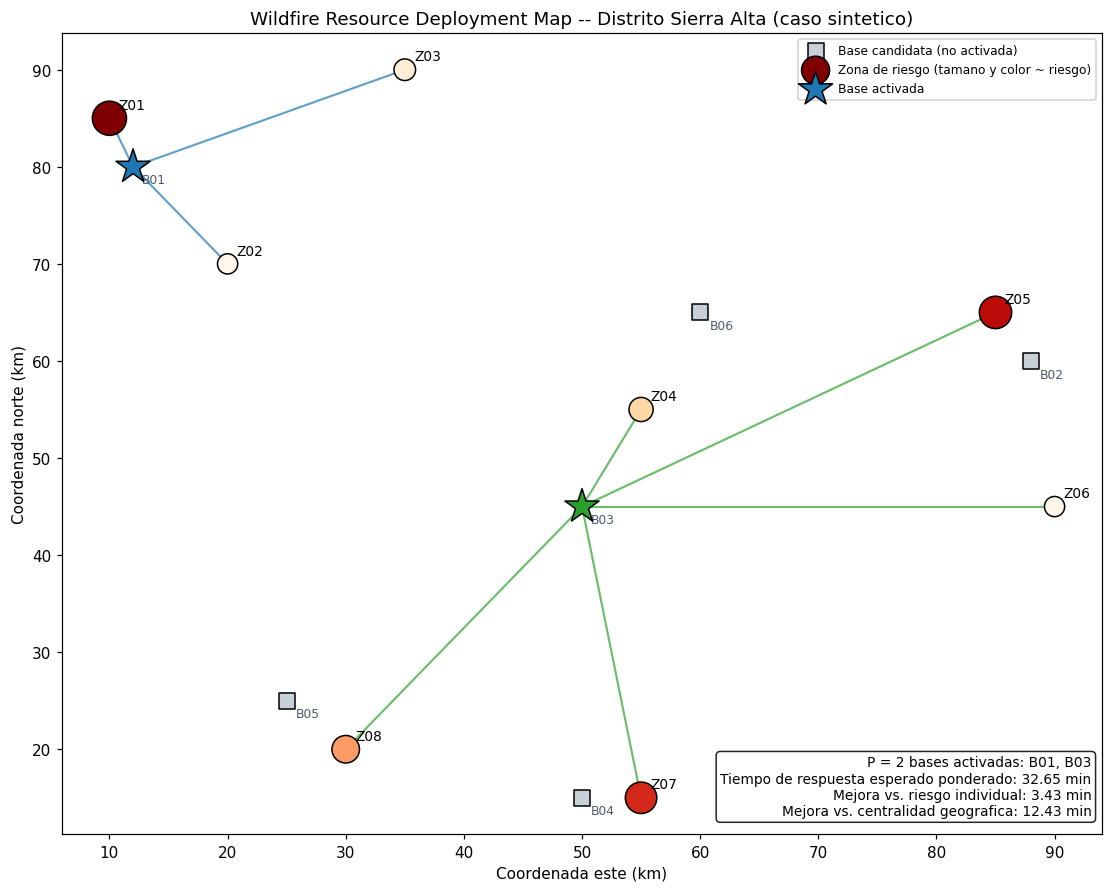

In [29]:
# El mapa completo es el producto de decision: donde posicionar recursos antes del incendio.

map_ax.set(
    xlabel="Coordenada este (km)", ylabel="Coordenada norte (km)",
    title="Wildfire Resource Deployment Map -- Distrito Sierra Alta (caso sintetico)",
)
map_ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
summary_text = (
    f"P = {P} bases activadas: {', '.join(solver_bases)}\n"
    f"Tiempo de respuesta esperado ponderado: {solver_objective:.2f} min\n"
    f"Mejora vs. riesgo individual: {risk_first_objective - solver_objective:.2f} min\n"
    f"Mejora vs. centralidad geografica: {centrality_objective - solver_objective:.2f} min"
)
map_ax.text(
    0.99, 0.02, summary_text, transform=map_ax.transAxes, ha="right", va="bottom",
    fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
)
display(planner)

In [30]:
# Verificamos el caso completo antes de generar los artefactos de entrega.

assert np.isclose(zones.risk_weight.sum(), 1.0)
assert len(exhaustive_bases) == P and optimal_count == 1
assert exhaustive_objective < second_best_objective
assert pulp.LpStatus[status] == "Optimal"
assert np.isclose(solver_objective, exhaustive_objective)
assert solver_bases == exhaustive_bases
assert solver_assignment == exhaustive_assignment
assert resource_sensitivity.bases_to_activate.tolist() == [1, 2, 3]
assert (resource_sensitivity.expected_response_time_min.diff().dropna() <= 1e-6).all()
baseline_row = resource_sensitivity.loc[
    resource_sensitivity.bases_to_activate == P, "expected_response_time_min"
].iloc[0]
assert np.isclose(baseline_row, exhaustive_objective)
assert risk_first_objective >= exhaustive_objective and centrality_objective >= exhaustive_objective
print("Verificado: optimo unico, HiGHS coincide con la busqueda exhaustiva y la sensibilidad es consistente.")

Verificado: optimo unico, HiGHS coincide con la busqueda exhaustiva y la sensibilidad es consistente.


In [31]:
# Guardamos las decisiones del escenario base y el mapa completo; no se vuelve a mostrar.

submission_dir.mkdir(exist_ok=True)
deployment_decisions.to_csv(submission_dir / "deployment_decisions.csv", index=False)
zone_assignments[
    [
        "zone_id", "assigned_base", "risk_weight", "distance_km",
        "response_time_min", "weighted_response_contribution",
    ]
].to_csv(submission_dir / "zone_assignments.csv", index=False)
resource_sensitivity.to_csv(submission_dir / "resource_sensitivity.csv", index=False)
planner.savefig(
    submission_dir / "wildfire_resource_deployment_map.png", dpi=180, bbox_inches="tight", facecolor="white"
)
display(
    [
        str(submission_dir / name)
        for name in [
            "deployment_decisions.csv",
            "zone_assignments.csv",
            "resource_sensitivity.csv",
            "wildfire_resource_deployment_map.png",
        ]
    ]
)

['../submission/deployment_decisions.csv',
 '../submission/zone_assignments.csv',
 '../submission/resource_sensitivity.csv',
 '../submission/wildfire_resource_deployment_map.png']